# Fase 1 - Setup e Carregamento dos Dados

**Grupo 18 - Mineracao de Dados - UFMG**

Carregamento multi-ano (2023-2026) de ocorrencias da PRF em MG via `src/data_loading.py`.
Arquivos em `data/`: `datatran{ano}.csv` (ver `data/README.md`).

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.config import (
    ANOS_OCORRENCIA,
    COLUNAS_CONTEXTO,
    DATA_DIR,
    DADOS_DIR,
    FIGURAS_DIR,
    FILTRO_UF,
    MIN_SUPPORT,
    PROCESSED_DIR,
    TABELAS_DIR,
)

plt.rcParams["figure.figsize"] = (11, 5)
sns.set_style("whitegrid")
FIGURAS_DIR.mkdir(parents=True, exist_ok=True)

## 1.1 Anos disponiveis e carregamento

In [2]:
from src.data_loading import carregar_anos, listar_anos_disponiveis, resumo_por_ano

mapa = listar_anos_disponiveis()
print("Arquivos encontrados:")
for ano, path in sorted(mapa.items()):
    print(f"  {ano}: {path.name}")

df, mapa_anos = carregar_anos(ignorar_ausentes=True)
print(f"\nUF filtro: {FILTRO_UF} | Anos: {ANOS_OCORRENCIA}")
print(f"Registros totais: {len(df):,} | Colunas: {len(df.columns)}")

Arquivos encontrados:
  2023: datatran2023.csv
  2024: datatran2024.csv
  2025: datatran2025.csv
  2026: datatran2026.csv
[OK] Anos carregados: [2023, 2024, 2025, 2026] | Registros: 30,858

UF filtro: MG | Anos: [2023, 2024, 2025, 2026]
Registros totais: 30,858 | Colunas: 32


## 1.2 Resumo por ano

,ano,n_ocorrencias,pct_fatais,pct_com_vitimas,arquivo
0,2023,9007,6.75,87.33,datatran2023.csv
1,2024,9296,6.88,87.04,datatran2024.csv
2,2025,9570,6.76,87.39,datatran2025.csv
3,2026,2985,7.07,86.40,datatran2026.csv


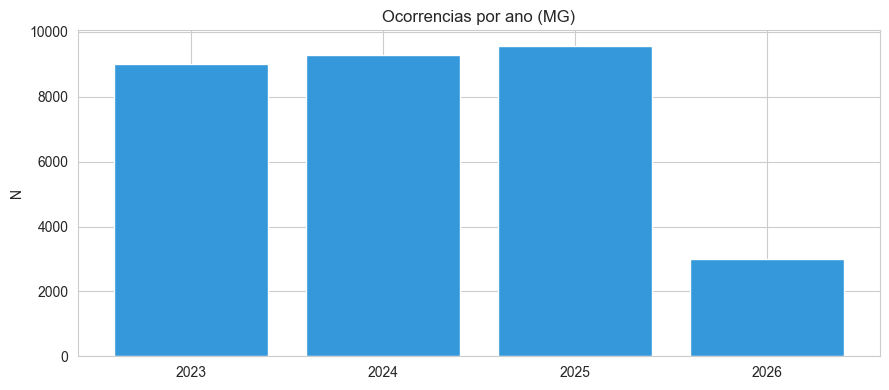

In [3]:
resumo = resumo_por_ano(df)
display(resumo)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(resumo["ano"].astype(str), resumo["n_ocorrencias"], color="#3498db")
ax.set_title("Ocorrencias por ano (MG)")
ax.set_ylabel("N")
fig.tight_layout()
fig.savefig(FIGURAS_DIR / "00_ocorrencias_por_ano.png", dpi=200)
plt.show()

## 1.3 Qualidade e amostra

In [4]:
print("Valores ausentes (top 10):")
print(df.isna().sum().sort_values(ascending=False).head(10))
print("\nClassificacao bruta:")
print(df["classificacao_acidente"].value_counts())
display(df[["id", "ano", "data_inversa", "municipio", "br", "classificacao_acidente", "tipo_acidente"]].head(8))

Valores ausentes (top 10):
uop               6
delegacia         4
regional          3
id                0
uf                0
data_inversa      0
dia_semana        0
horario           0
causa_acidente    0
tipo_acidente     0
dtype: int64

Classificacao bruta:
classificacao_acidente
Com Vítimas Feridas    24793
Sem Vítimas             3959
Com Vítimas Fatais      2106
Name: count, dtype: int64


,id,ano,data_inversa,municipio,br,classificacao_acidente,tipo_acidente
0,496659.0,2023,2023-01-01,MANHUACU,116,Com Vítimas Feridas,Colisão frontal
1,496671.0,2023,2023-01-01,CORREGO DANTA,262,Sem Vítimas,Saída de leito carroçável
2,496686.0,2023,2023-01-01,CAMBUI,381,Sem Vítimas,Incêndio
3,496712.0,2023,2023-01-01,SAO GONCALO DO RIO ABAIXO,381,Sem Vítimas,Incêndio
4,496795.0,2023,2023-01-02,PATOS DE MINAS,365,Com Vítimas Feridas,Colisão lateral sentido oposto
5,496807.0,2023,2023-01-02,MONTE ALEGRE DE MINAS,365,Com Vítimas Feridas,Tombamento
6,496811.0,2023,2023-01-02,SAO GONCALO DO RIO ABAIXO,381,Com Vítimas Feridas,Derramamento de carga
7,496818.0,2023,2023-01-02,NOVA ERA,381,Com Vítimas Fatais,Colisão lateral sentido oposto


## 1.4 Checklist

In [5]:
for k, v in {
    "Anos carregados": sorted(mapa_anos.keys()),
    "Registros MG": len(df),
    "Arquivos em data/": len(mapa),
    "Pct com vitimas (media)": round(resumo["pct_com_vitimas"].mean(), 1),
}.items():
    print(f"  [OK] {k}: {v}")

  [OK] Anos carregados: [2023, 2024, 2025, 2026]
  [OK] Registros MG: 30858
  [OK] Arquivos em data/: 4
  [OK] Pct com vitimas (media): 87.0
